<a href="https://colab.research.google.com/github/eepsaranjan/Fraud-Transaction-Detection/blob/main/FraudDetect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
path='/content/drive/MyDrive/Colab Notebooks/Data Set/Fraud Detection Transactions Dataset.csv'

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler

from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn import tree
from IPython.display import SVG
from graphviz import Source
from IPython.display import display

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV

In [84]:
df=pd.read_csv(path)
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [85]:
df.shape

(50000, 21)

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  object 
 4   Timestamp                     50000 non-null  object 
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  object 
 7   Location                      50000 non-null  object 
 8   Merchant_Category             50000 non-null  object 
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  F

In [87]:
m=df.isnull().sum()
m

,0
Transaction_ID,0
User_ID,0
Transaction_Amount,0
Transaction_Type,0
Timestamp,0
Account_Balance,0
Device_Type,0
Location,0
Merchant_Category,0
IP_Address_Flag,0


In [88]:
df.drop(columns=['Transaction_ID', 'User_ID'], inplace=True)
df.head()

,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,0,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,0,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,0,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,0,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,1,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [89]:
df['Transaction_Type'].value_counts()

,count
Transaction_Type,
POS,12549
Online,12546
ATM Withdrawal,12453
Bank Transfer,12452


In [90]:
df['Device_Type'].value_counts()

,count
Device_Type,
Tablet,16779
Mobile,16640
Laptop,16581


In [91]:
df['Location'].value_counts()

,count
Location,
Tokyo,10208
Mumbai,9994
London,9945
Sydney,9938
New York,9915


In [92]:
df['Merchant_Category'].value_counts()

,count
Merchant_Category,
Clothing,10033
Groceries,10019
Travel,10015
Restaurants,9976
Electronics,9957


In [93]:
df['Card_Type'].value_counts()

,count
Card_Type,
Mastercard,12693
Visa,12560
Amex,12419
Discover,12328


In [94]:
df['Authentication_Method'].value_counts()

,count
Authentication_Method,
Biometric,12591
PIN,12586
Password,12457
OTP,12366


In [95]:
df=pd.get_dummies(df,columns=['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category', 'Card_Type', 'Authentication_Method'])
df.head()

,Transaction_Amount,Timestamp,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,...,Merchant_Category_Restaurants,Merchant_Category_Travel,Card_Type_Amex,Card_Type_Discover,Card_Type_Mastercard,Card_Type_Visa,Authentication_Method_Biometric,Authentication_Method_OTP,Authentication_Method_PIN,Authentication_Method_Password
0,39.79,2023-08-14 19:30:00,93213.17,0,0,7,437.63,3,65,883.17,...,False,True,True,False,False,False,True,False,False,False
1,1.19,2023-06-07 04:01:00,75725.25,0,0,13,478.76,4,186,2203.36,...,False,False,False,False,True,False,False,False,False,True
2,28.96,2023-06-20 15:25:00,1588.96,0,0,14,50.01,4,226,1909.29,...,True,False,False,False,False,True,True,False,False,False
3,254.32,2023-12-07 00:31:00,76807.20,0,0,8,182.48,4,76,1311.86,...,False,False,False,False,False,True,False,True,False,False
4,31.28,2023-11-11 23:44:00,92354.66,0,1,14,328.69,4,140,966.98,...,False,False,False,False,True,False,False,False,False,True


In [96]:
df['Timestamp']=pd.to_datetime(df['Timestamp'])
df['Day']=df['Timestamp'].dt.day
df['Month']=df['Timestamp'].dt.month
df['Year']=df['Timestamp'].dt.year
df['Hour']=df['Timestamp'].dt.hour
df['Minute']=df['Timestamp'].dt.minute
df.drop(columns=['Timestamp'], inplace=True)
df.head()

,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,...,Card_Type_Visa,Authentication_Method_Biometric,Authentication_Method_OTP,Authentication_Method_PIN,Authentication_Method_Password,Day,Month,Year,Hour,Minute
0,39.79,93213.17,0,0,7,437.63,3,65,883.17,0.8494,...,False,True,False,False,False,14,8,2023,19,30
1,1.19,75725.25,0,0,13,478.76,4,186,2203.36,0.0959,...,False,False,False,False,True,7,6,2023,4,1
2,28.96,1588.96,0,0,14,50.01,4,226,1909.29,0.8400,...,True,True,False,False,False,20,6,2023,15,25
3,254.32,76807.20,0,0,8,182.48,4,76,1311.86,0.7935,...,True,False,True,False,False,7,12,2023,0,31
4,31.28,92354.66,0,1,14,328.69,4,140,966.98,0.3819,...,False,False,False,False,True,11,11,2023,23,44


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 42 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Transaction_Amount               50000 non-null  float64
 1   Account_Balance                  50000 non-null  float64
 2   IP_Address_Flag                  50000 non-null  int64  
 3   Previous_Fraudulent_Activity     50000 non-null  int64  
 4   Daily_Transaction_Count          50000 non-null  int64  
 5   Avg_Transaction_Amount_7d        50000 non-null  float64
 6   Failed_Transaction_Count_7d      50000 non-null  int64  
 7   Card_Age                         50000 non-null  int64  
 8   Transaction_Distance             50000 non-null  float64
 9   Risk_Score                       50000 non-null  float64
 10  Is_Weekend                       50000 non-null  int64  
 11  Fraud_Label                      50000 non-null  int64  
 12  Transaction_Type_A

In [98]:
x = df.drop('Fraud_Label',axis = 1)
y = df['Fraud_Label']

In [99]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42,stratify = y)

In [100]:
model = LogisticRegression(max_iter=5000)

In [101]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [102]:
model = LogisticRegression(max_iter=5000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=5000)

In [103]:
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

In [104]:
train_pred[:5]

array([0, 0, 0, 0, 0])

In [105]:
y_train[:5]

,Fraud_Label
3133,0
5433,0
7621,0
22601,0
40066,0


In [106]:
print('Train Confusion Matrix :-\n',confusion_matrix(y_train,train_pred))
print('Train Accuracfy :-',accuracy_score(y_train,train_pred))
print('Train Precision Score :-',precision_score(y_train,train_pred))
print('Train Recall Score :-',recall_score(y_train,train_pred))

Train Confusion Matrix :-
 [[24041  3105]
 [ 4484  8370]]
Train Accuracfy :- 0.810275
Train Precision Score :- 0.7294117647058823
Train Recall Score :- 0.6511591722421036


In [107]:
print('Test confusion matrix :-\n',confusion_matrix(y_test,test_pred))
print('Test Accuracy :-',accuracy_score(y_test,test_pred))
print('Test Precision Score :-',precision_score(y_test,test_pred))
print('Test Recall Score :-',recall_score(y_test,test_pred))

Test confusion matrix :-
 [[5927  860]
 [1145 2068]]
Test Accuracy :- 0.7995
Test Precision Score :- 0.7062841530054644
Test Recall Score :- 0.643635231870526


In [108]:
model = DecisionTreeClassifier()
model.fit(x_train, y_train)

DecisionTreeClassifier()

In [109]:
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

In [110]:
train_pred[:5]

array([0, 0, 0, 0, 0])

In [111]:
y_train[:5]

,Fraud_Label
3133,0
5433,0
7621,0
22601,0
40066,0


In [112]:
print('Train Confusion Matrix :-\n',confusion_matrix(y_train,train_pred))
print('Train Accuracfy :-',accuracy_score(y_train,train_pred))
print('Train Precision Score :-',precision_score(y_train,train_pred))
print('Train Recall Score :-',recall_score(y_train,train_pred))

Train Confusion Matrix :-
 [[27146     0]
 [    0 12854]]
Train Accuracfy :- 1.0
Train Precision Score :- 1.0
Train Recall Score :- 1.0


In [113]:
print('Test confusion matrix :-\n',confusion_matrix(y_test,test_pred))
print('Test Accuracy :-',accuracy_score(y_test,test_pred))
print('Test Precision Score :-',precision_score(y_test,test_pred))
print('Test Recall Score :-',recall_score(y_test,test_pred))

Test confusion matrix :-
 [[6787    0]
 [   0 3213]]
Test Accuracy :- 1.0
Test Precision Score :- 1.0
Test Recall Score :- 1.0


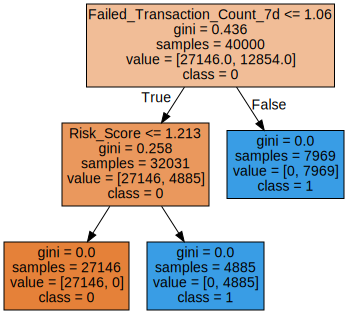

In [114]:
graph = Source(tree.export_graphviz(model, out_file=None
   , feature_names=x.columns, class_names=['0', '1']
   , filled = True))
display(SVG(graph.pipe(format='svg')))